In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nehamalav/hhs-un/HHS_Unaccompanied_Alien_Children_Program (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files)

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/nehamalav
[]
/kaggle/input/datasets/nehamalav/hhs-un
['HHS_Unaccompanied_Alien_Children_Program (1).csv']


In [4]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/nehamalav/hhs-un/HHS_Unaccompanied_Alien_Children_Program (1).csv"
)

print(df.shape)
df.head()

(1170, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Date                                               datetime64[ns]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                      float64
Children discharged from HHS Care                         float64
dtype: object


In [6]:
print(df.isnull().sum())

Date                                                450
Children apprehended and placed in CBP custody*     450
Children in CBP custody                             450
Children transferred out of CBP custody             450
Children in HHS Care                               1170
Children discharged from HHS Care                   450
dtype: int64


In [7]:
df.fillna(0, inplace=True)

print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


/tmp/ipykernel_16/3210086146.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


In [8]:
import numpy as np

df["Transfer Efficiency Ratio"] = np.where(
    df["Children apprehended and placed in CBP custody*"] > 0,
    df["Children transferred out of CBP custody"] /
    df["Children apprehended and placed in CBP custody*"],
    np.nan
)

df["Discharge Efficiency Ratio"] = np.where(
    df["Children in HHS Care"] > 0,
    df["Children discharged from HHS Care"] /
    df["Children in HHS Care"],
    np.nan
)

df[["Transfer Efficiency Ratio", "Discharge Efficiency Ratio"]].head()

,Transfer Efficiency Ratio,Discharge Efficiency Ratio
0,1.833333,NaN
1,0.545455,NaN
2,1.571429,NaN
3,1.875000,NaN
4,0.818182,NaN


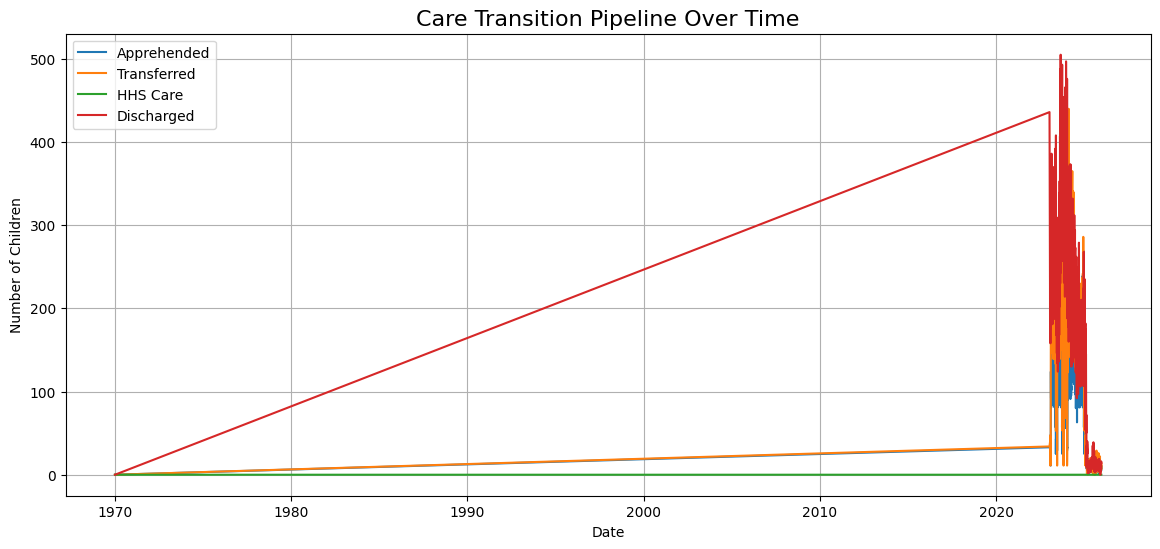

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Children apprehended and placed in CBP custody*"], label="Apprehended")
plt.plot(df["Date"], df["Children transferred out of CBP custody"], label="Transferred")
plt.plot(df["Date"], df["Children in HHS Care"], label="HHS Care")
plt.plot(df["Date"], df["Children discharged from HHS Care"], label="Discharged")

plt.title("Care Transition Pipeline Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True)

plt.show()

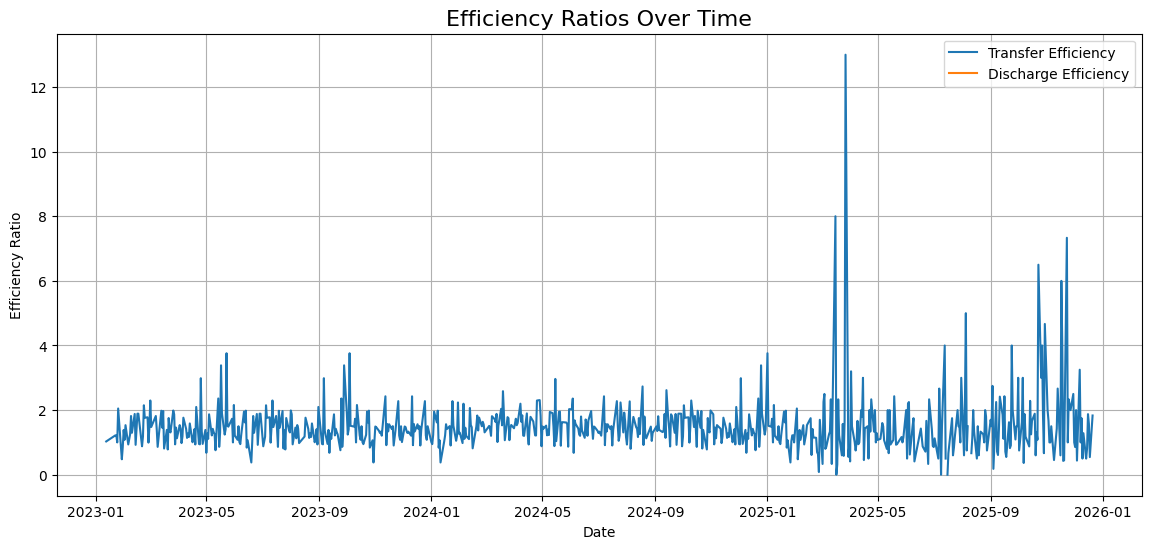

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Transfer Efficiency Ratio"], label="Transfer Efficiency")
plt.plot(df["Date"], df["Discharge Efficiency Ratio"], label="Discharge Efficiency")

plt.title("Efficiency Ratios Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Efficiency Ratio")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio
count,1170.000000,1170.000000,1170.000000,1170.0,1170.000000,718.000000,0.0
mean,57.552991,105.535043,79.180342,0.0,106.711966,1.484338,NaN
std,72.924368,129.563500,98.728672,0.0,129.776191,0.856793,NaN
min,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,NaN
25%,0.000000,0.000000,0.000000,0.0,0.000000,1.030303,NaN
50%,9.000000,29.000000,11.000000,0.0,14.000000,1.386364,NaN
75%,115.000000,220.000000,169.000000,0.0,210.000000,1.760419,NaN
max,333.000000,531.000000,440.000000,0.0,505.000000,13.000000,NaN


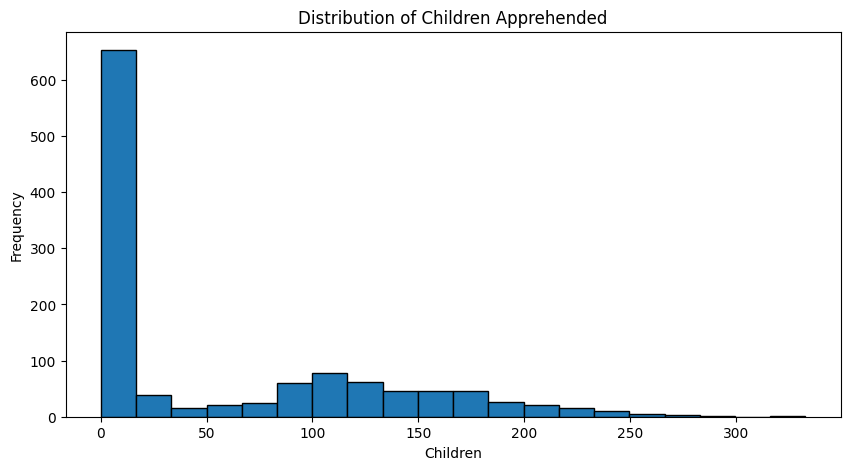

In [12]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Children apprehended and placed in CBP custody*"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Children Apprehended")
plt.xlabel("Children")
plt.ylabel("Frequency")

plt.show()

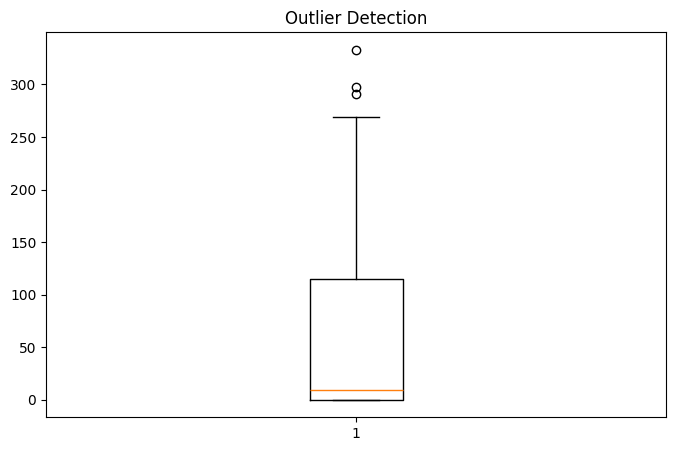

In [13]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["Children apprehended and placed in CBP custody*"]
)

plt.title("Outlier Detection")

plt.show()

In [14]:
correlation = df.select_dtypes(include=["number"]).corr()

correlation

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio
Children apprehended and placed in CBP custody*,1.000000,0.970148,0.932206,NaN,0.778504,-0.164238,NaN
Children in CBP custody,0.970148,1.000000,0.955594,NaN,0.768815,-0.079312,NaN
Children transferred out of CBP custody,0.932206,0.955594,1.000000,NaN,0.798539,0.050046,NaN
Children in HHS Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Children discharged from HHS Care,0.778504,0.768815,0.798539,NaN,1.000000,-0.044777,NaN
Transfer Efficiency Ratio,-0.164238,-0.079312,0.050046,NaN,-0.044777,1.000000,NaN
Discharge Efficiency Ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN


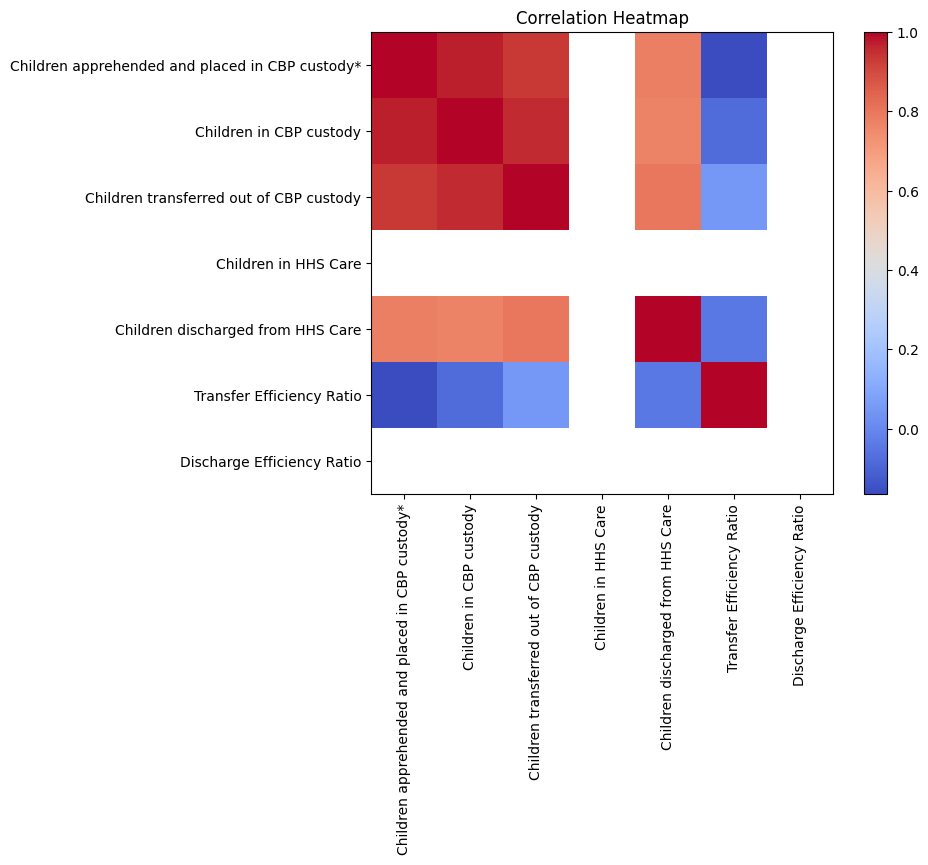

In [15]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[ns]


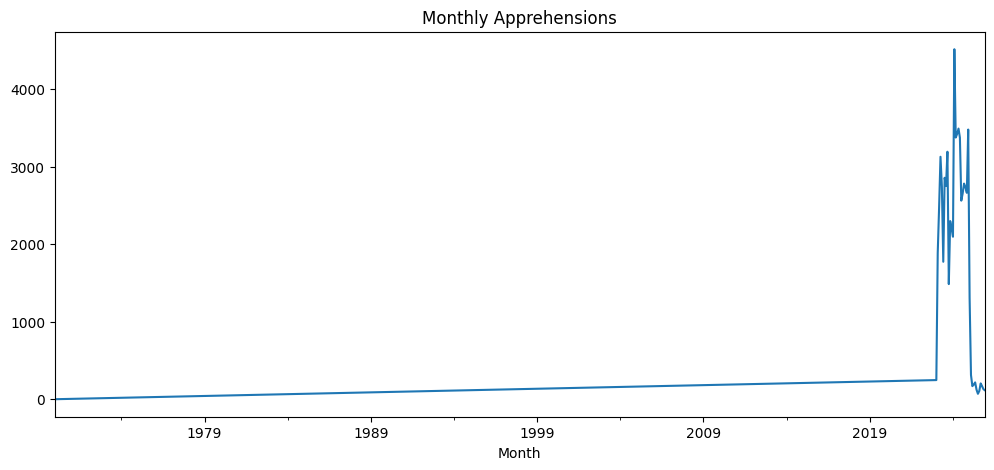

In [17]:
df["Month"] = df["Date"].dt.to_period("M")

monthly = (
    df.groupby("Month")[
        "Children apprehended and placed in CBP custody*"
    ]
    .sum()
)

monthly.plot(figsize=(12,5))

plt.title("Monthly Apprehensions")

plt.show()

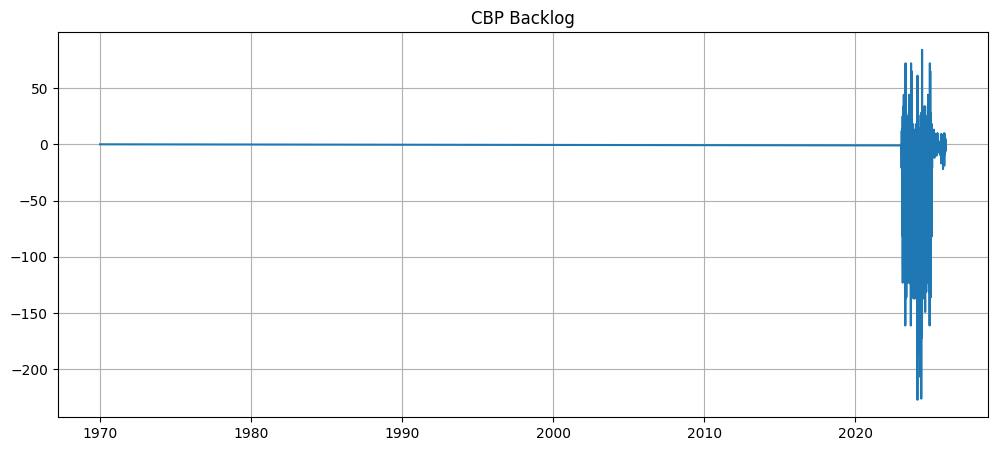

In [18]:
df["CBP Backlog"] = (
    df["Children apprehended and placed in CBP custody*"]
    -
    df["Children transferred out of CBP custody"]
)

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["CBP Backlog"])

plt.title("CBP Backlog")

plt.grid(True)

plt.show()

In [19]:
import numpy as np

df["Transfer Efficiency Ratio"] = np.where(
    df["Children apprehended and placed in CBP custody*"] > 0,
    df["Children transferred out of CBP custody"] /
    df["Children apprehended and placed in CBP custody*"],
    np.nan
)

df["Transfer Efficiency Ratio"].head()

0    1.833333
1    0.545455
2    1.571429
3    1.875000
4    0.818182
Name: Transfer Efficiency Ratio, dtype: float64

In [20]:
df["Discharge Efficiency Ratio"] = np.where(
    df["Children in HHS Care"] > 0,
    df["Children discharged from HHS Care"] /
    df["Children in HHS Care"],
    np.nan
)

df["Discharge Efficiency Ratio"].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Discharge Efficiency Ratio, dtype: float64

In [21]:
df[[
    "Transfer Efficiency Ratio",
    "Discharge Efficiency Ratio"
]].describe()

,Transfer Efficiency Ratio,Discharge Efficiency Ratio
count,718.000000,0.0
mean,1.484338,NaN
std,0.856793,NaN
min,0.000000,NaN
25%,1.030303,NaN
50%,1.386364,NaN
75%,1.760419,NaN
max,13.000000,NaN


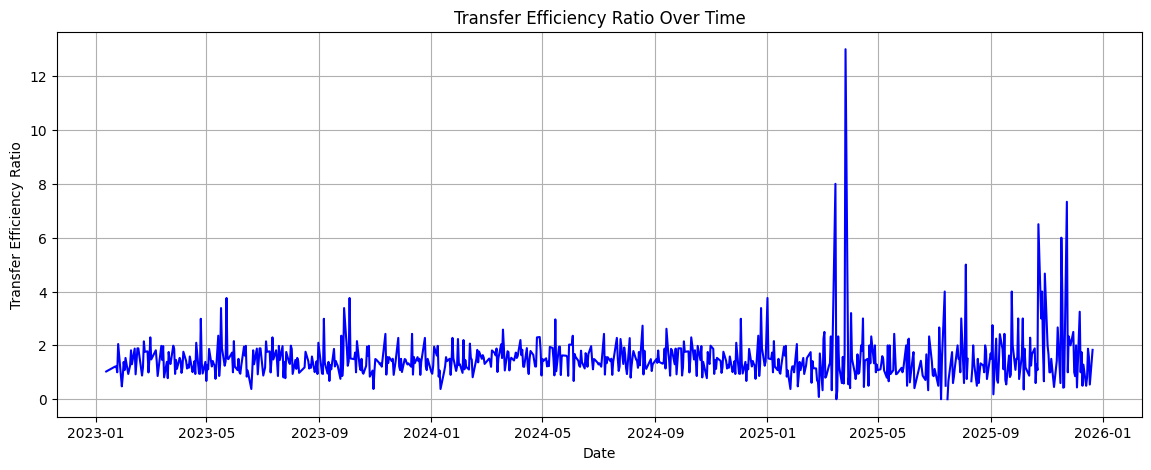

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["Transfer Efficiency Ratio"], color="blue")

plt.title("Transfer Efficiency Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Transfer Efficiency Ratio")
plt.grid(True)

plt.show()

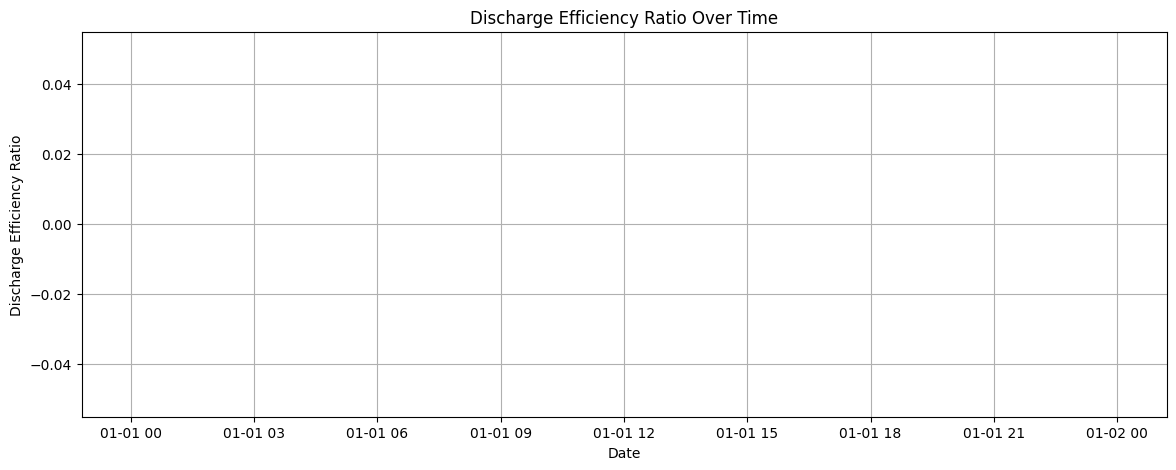

In [23]:
plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["Discharge Efficiency Ratio"], color="green")

plt.title("Discharge Efficiency Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Discharge Efficiency Ratio")
plt.grid(True)

plt.show()

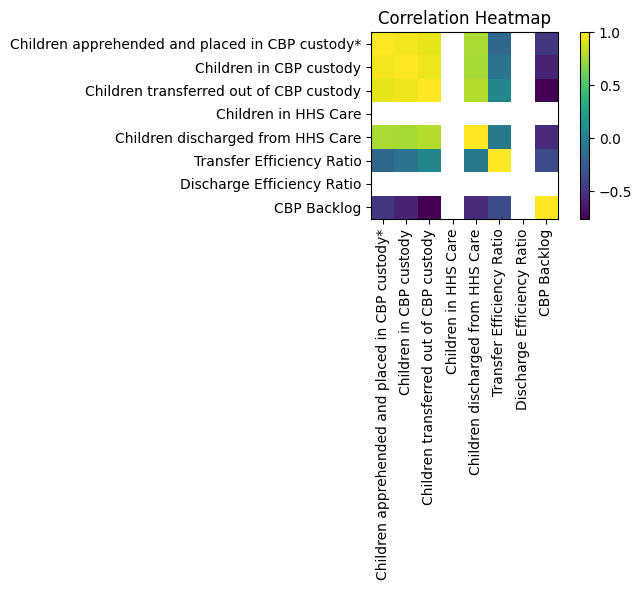

In [24]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [25]:
print("=" * 50)
print("CARE TRANSITION ANALYTICS DASHBOARD")
print("=" * 50)

print(f"Total Records: {len(df)}")

print(f"Average Transfer Efficiency: {df['Transfer Efficiency Ratio'].mean():.2f}")

print(f"Average Discharge Efficiency: {df['Discharge Efficiency Ratio'].mean():.2f}")

print(f"Average Children in HHS Care: {df['Children in HHS Care'].mean():.0f}")

print(f"Average CBP Custody: {df['Children in CBP custody'].mean():.0f}")

CARE TRANSITION ANALYTICS DASHBOARD
Total Records: 1170
Average Transfer Efficiency: 1.48
Average Discharge Efficiency: nan
Average Children in HHS Care: 0
Average CBP Custody: 106


In [26]:
top10 = df.sort_values(
    "Children apprehended and placed in CBP custody*",
    ascending=False
)

top10[[
    "Date",
    "Children apprehended and placed in CBP custody*"
]].head(10)

,Date,Children apprehended and placed in CBP custody*
457,2024-02-15,333.0
462,2024-02-08,298.0
464,2024-02-06,291.0
555,2023-09-24,269.0
644,2023-05-11,269.0
246,2024-12-19,269.0
448,2024-02-29,262.0
381,2024-06-04,260.0
466,2024-02-04,253.0
409,2024-04-24,253.0


In [27]:
df["CBP Backlog"] = (
    df["Children apprehended and placed in CBP custody*"]
    -
    df["Children transferred out of CBP custody"]
)

df.sort_values(
    "CBP Backlog",
    ascending=False
)[[
    "Date",
    "CBP Backlog"
]].head(10)

,Date,CBP Backlog
381,2024-06-04,84.0
652,2023-05-01,72.0
254,2024-12-09,72.0
563,2023-09-12,72.0
555,2023-09-24,65.0
246,2024-12-19,65.0
644,2023-05-11,65.0
457,2024-02-15,61.0
682,2023-03-20,44.0
593,2023-07-26,44.0


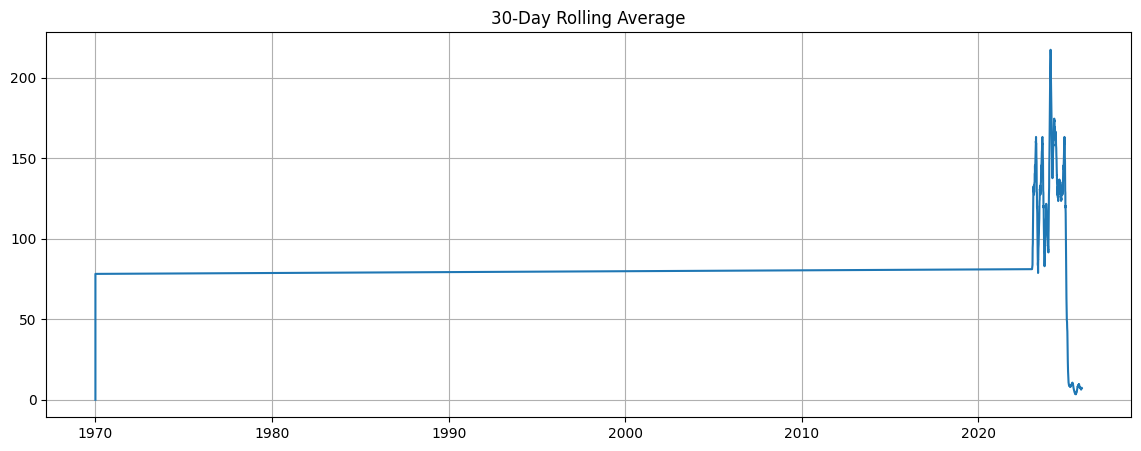

In [28]:
rolling = (
    df["Children apprehended and placed in CBP custody*"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(df["Date"], rolling)

plt.title("30-Day Rolling Average")

plt.grid(True)

plt.show()

In [29]:
dashboard = df.groupby(df["Date"].dt.to_period("M")).agg({

    "Children apprehended and placed in CBP custody*":"sum",

    "Children transferred out of CBP custody":"sum",

    "Children discharged from HHS Care":"sum",

    "Transfer Efficiency Ratio":"mean",

    "Discharge Efficiency Ratio":"mean"

})

dashboard

,Children apprehended and placed in CBP custody*,Children transferred out of CBP custody,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio
Date,,,,,
1970-01,0.0,0.0,0.0,NaN,NaN
2023-01,247.0,276.0,1856.0,1.154203,NaN
2023-02,1886.0,2637.0,5183.0,1.433319,NaN
2023-03,2479.0,3399.0,5375.0,1.477867,NaN
2023-04,3129.0,3967.0,5668.0,1.364588,NaN
2023-05,2746.0,3622.0,6256.0,1.591796,NaN
2023-06,1774.0,2416.0,4029.0,1.349358,NaN
2023-07,2858.0,3897.0,4407.0,1.471804,NaN
2023-08,2751.0,3587.0,6470.0,1.373105,NaN


In [30]:
df.to_csv(
    "Processed_HHS_Analytics.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [31]:
monthly_dashboard = df.groupby(df["Date"].dt.to_period("M")).agg({
    "Children apprehended and placed in CBP custody*":"sum",
    "Children transferred out of CBP custody":"sum",
    "Children in HHS Care":"mean",
    "Children discharged from HHS Care":"sum",
    "Transfer Efficiency Ratio":"mean",
    "Discharge Efficiency Ratio":"mean"
})

monthly_dashboard

,Children apprehended and placed in CBP custody*,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio
Date,,,,,,
1970-01,0.0,0.0,0.0,0.0,NaN,NaN
2023-01,247.0,276.0,0.0,1856.0,1.154203,NaN
2023-02,1886.0,2637.0,0.0,5183.0,1.433319,NaN
2023-03,2479.0,3399.0,0.0,5375.0,1.477867,NaN
2023-04,3129.0,3967.0,0.0,5668.0,1.364588,NaN
2023-05,2746.0,3622.0,0.0,6256.0,1.591796,NaN
2023-06,1774.0,2416.0,0.0,4029.0,1.349358,NaN
2023-07,2858.0,3897.0,0.0,4407.0,1.471804,NaN
2023-08,2751.0,3587.0,0.0,6470.0,1.373105,NaN


In [32]:
monthly_dashboard.to_csv("Monthly_Dashboard.csv")

print("Dashboard Saved Successfully")

Dashboard Saved Successfully


In [33]:
top10 = df.sort_values(
    "Children apprehended and placed in CBP custody*",
    ascending=False
)

top10.head(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio,Month,CBP Backlog
457,2024-02-15,333.0,508.0,272.0,0.0,312.0,0.816817,NaN,2024-02,61.0
462,2024-02-08,298.0,499.0,358.0,0.0,315.0,1.201342,NaN,2024-02,-60.0
464,2024-02-06,291.0,455.0,323.0,0.0,178.0,1.109966,NaN,2024-02,-32.0
555,2023-09-24,269.0,412.0,204.0,0.0,403.0,0.758364,NaN,2023-09,65.0
644,2023-05-11,269.0,412.0,204.0,0.0,392.0,0.758364,NaN,2023-05,65.0
246,2024-12-19,269.0,412.0,204.0,0.0,238.0,0.758364,NaN,2024-12,65.0
448,2024-02-29,262.0,444.0,354.0,0.0,299.0,1.351145,NaN,2024-02,-92.0
381,2024-06-04,260.0,356.0,176.0,0.0,203.0,0.676923,NaN,2024-06,84.0
466,2024-02-04,253.0,531.0,248.0,0.0,342.0,0.980237,NaN,2024-02,5.0
409,2024-04-24,253.0,411.0,307.0,0.0,154.0,1.213439,NaN,2024-04,-54.0


In [34]:
df["Backlog"] = (
    df["Children apprehended and placed in CBP custody*"]
    -
    df["Children transferred out of CBP custody"]
)

df.sort_values(
    "Backlog",
    ascending=False
).head(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Efficiency Ratio,Month,CBP Backlog,Backlog
381,2024-06-04,260.0,356.0,176.0,0.0,203.0,0.676923,NaN,2024-06,84.0,84.0
652,2023-05-01,224.0,315.0,152.0,0.0,237.0,0.678571,NaN,2023-05,72.0,72.0
254,2024-12-09,224.0,315.0,152.0,0.0,174.0,0.678571,NaN,2024-12,72.0,72.0
563,2023-09-12,224.0,315.0,152.0,0.0,316.0,0.678571,NaN,2023-09,72.0,72.0
555,2023-09-24,269.0,412.0,204.0,0.0,403.0,0.758364,NaN,2023-09,65.0,65.0
246,2024-12-19,269.0,412.0,204.0,0.0,238.0,0.758364,NaN,2024-12,65.0,65.0
644,2023-05-11,269.0,412.0,204.0,0.0,392.0,0.758364,NaN,2023-05,65.0,65.0
457,2024-02-15,333.0,508.0,272.0,0.0,312.0,0.816817,NaN,2024-02,61.0,61.0
682,2023-03-20,202.0,313.0,158.0,0.0,279.0,0.782178,NaN,2023-03,44.0,44.0
593,2023-07-26,202.0,313.0,158.0,0.0,215.0,0.782178,NaN,2023-07,44.0,44.0


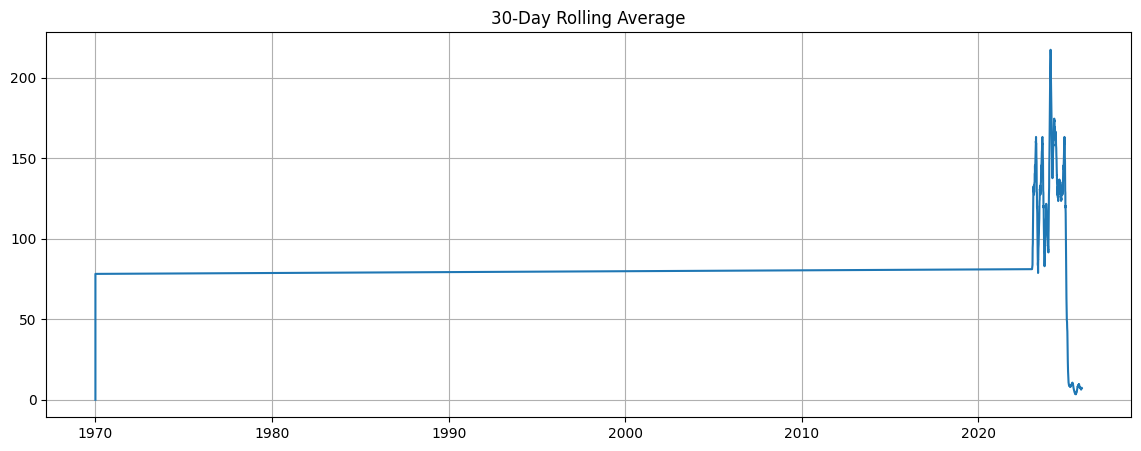

In [35]:
rolling = df[
    "Children apprehended and placed in CBP custody*"
].rolling(30).mean()

plt.figure(figsize=(14,5))

plt.plot(df["Date"], rolling)

plt.title("30-Day Rolling Average")

plt.grid(True)

plt.show()

In [36]:
print("="*60)

print("EXECUTIVE DASHBOARD")

print("="*60)

print("Total Records :", len(df))

print("Average Apprehensions :", round(
    df["Children apprehended and placed in CBP custody*"].mean(),2))

print("Average Transfer Ratio :", round(
    df["Transfer Efficiency Ratio"].mean(),2))

print("Average Discharge Ratio :", round(
    df["Discharge Efficiency Ratio"].mean(),2))

print("Average HHS Care :", round(
    df["Children in HHS Care"].mean(),2))

EXECUTIVE DASHBOARD
Total Records : 1170
Average Apprehensions : 57.55
Average Transfer Ratio : 1.48
Average Discharge Ratio : nan
Average HHS Care : 0.0


In [37]:
df.to_csv("Cleaned_HHS_Analytics.csv", index=False)

print("Project Dataset Saved Successfully")

Project Dataset Saved Successfully
